In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [21]:
file = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/morel_fq_hyperspectral.nc"
ds = xr.open_dataset(file, engine="netcdf4")

wave = ds.wave.values
solz = ds.solz.values
phi  = ds.phi.values  # relative azimuth angle
tau  = ds.tau.values
senz = ds.senz.values
chl  = ds.chl.values

foq  = ds.foq
foq_tau = ds.foq_tau

In [7]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:  (wave: 70, solz: 6, chl: 6, senz: 10, phi: 7, tau: 5)
Coordinates:
  * wave     (wave) float32 280B 352.5 357.5 362.5 367.5 ... 687.5 692.5 697.5
  * solz     (solz) float32 24B 0.0 15.0 30.0 45.0 60.0 75.0
  * chl      (chl) float32 24B 0.03 0.1 0.3 1.0 3.0 10.0
  * senz     (senz) float32 40B 0.0 2.194 6.937 12.79 ... 37.35 43.54 49.73
  * phi      (phi) float32 28B 0.0 30.0 60.0 90.0 120.0 150.0 180.0
  * tau      (tau) float32 20B 0.05 0.1 0.2 0.4 1.0
Data variables:
    foq      (wave, solz, chl, senz, phi) float32 706kB ...
    foq_tau  (wave, solz, tau, chl, senz, phi) float32 4MB ...
Attributes: (12/13)
    title:            Hyperspectral BRDF foq tables
    Conventions:      CF-1.8
    project:          Ocean Biology Processing Group (NASA/GSFC/OBPG)
    institution:      NASA Goddard Space Flight Center, Ocean Ecology Laborat...
    date_created:     2026-02-09T20:35:39.119Z
    foq_tau_for_c:    0.20000000298023224
    ...               ...
    creator_name:     NASA/GSFC/OBPG
    publisher_name:   NASA/GSFC/OBPG
    creator_email:    data@oceancolor.gsfc.nasa.gov
    publisher_email:  data@oceancolor.gsfc.nasa.gov
    creator_url:      https://oceandata.sci.gsfc.nasa.gov
    publisher_url:    https://oceandata.sci.gsfc.nasa.gov

In [ ]:
# select single wavelength
wave_idx = -4
target_wave = wave[wave_idx]
print(f"target_wave: {target_wave} nm")


target_wave: 682.5 nm


Text(0.5, 1.0, 'f/Q (fraction of photons?) @ 682.5 nm')

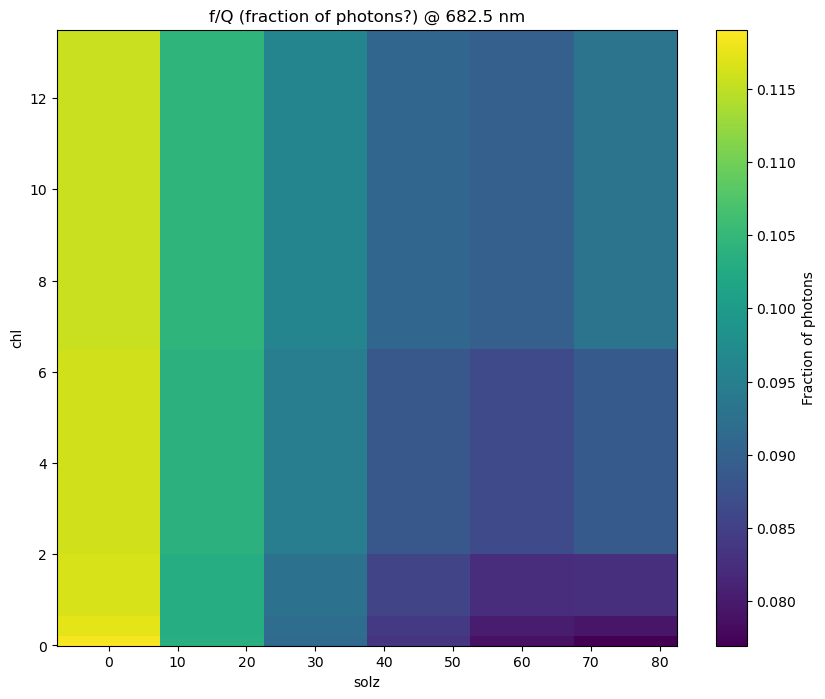

In [18]:
# heatmap of foq
plt.figure(figsize=(10, 8))
plt.pcolormesh(solz, chl, foq.values[wave_idx, :, :, 0, 0], cmap='viridis')
plt.colorbar(label='Fraction of photons')
plt.xlabel('solz')
plt.ylabel('chl')
plt.title(f'f/Q (fraction of photons?) @ {target_wave} nm')

/tmp/ipykernel_325307/1662567717.py:1: MatplotlibDeprecationWarning: Passing label as a length 6 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(wave, foq.values[:, 0, 2, 0, 0] / foq.values[:, 0, 4, 0, 0], label=chl)


(600.0, 700.0)

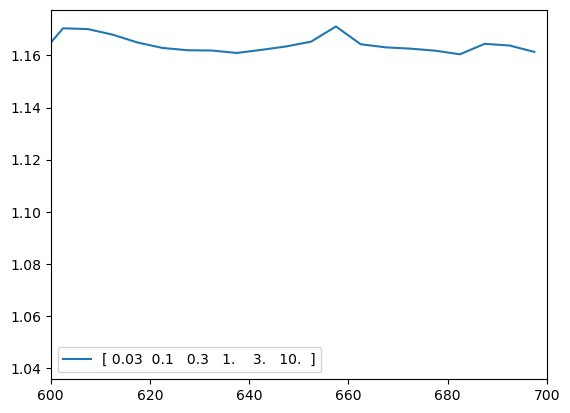

In [34]:
plt.plot(wave, foq.values[:, 0, 2, 0, 0] / foq.values[:, 0, 4, 0, 0], label=chl)
plt.legend()
plt.xlim(600, 700)